# Install & Import Library

In [12]:
%pip install torch
%pip install transformers
%pip install conllu
%pip install pandas numpy scikit-learn matplotlib tqdm
%pip install openpyxl
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 5.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.3/9.6 MB 3.9 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.6 MB 4.9 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 4.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 4.5 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 4.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 4.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.2 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import conllu
import os
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
from collections import defaultdict
import openpyxl

# Explore Dataset IndoLEM

## A. Explore Task Dataset - UD_Indonesian_GSD (RAW)

### 1. Set Path

In [3]:
BASE_PATH = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\raw\indolem-main\dependency_parsing"

PATH_GSD_TRAIN = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-train.conllu")
PATH_GSD_DEV   = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-dev.conllu")
PATH_GSD_TEST  = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-test.conllu")

### 2. Exploration Raw Data

In [4]:
# ============================================
# BACA DATA GSD
# ============================================
with open(PATH_GSD_TRAIN, "r", encoding="utf-8") as f:
    data_gsd_train = conllu.parse(f.read())
with open(PATH_GSD_DEV, "r", encoding="utf-8") as f:
    data_gsd_dev = conllu.parse(f.read())
with open(PATH_GSD_TEST, "r", encoding="utf-8") as f:
    data_gsd_test = conllu.parse(f.read())

data_gsd_all = data_gsd_train + data_gsd_dev + data_gsd_test

# ============================================
# AMBIL SAMPLE RAW DATA DARI GSD
# ============================================
raw_data = []

for kalimat in data_gsd_all:
    teks = kalimat.metadata.get('text', '')
    sent_id = kalimat.metadata.get('sent_id', '')
    
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
            
        raw_data.append({
            'sent_id'  : sent_id,
            'teks'     : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
        })

df_raw = pd.DataFrame(raw_data)

# ============================================
# TAMPILKAN STATISTIK LABEL
# ============================================
print("=" * 60)
print("INFORMASI RAW DATA UD-INDO-GSD")
print("=" * 60)

print(f"\n{'Jumlah kalimat (all)':<30}: {len(data_gsd_all)}")
print(f"{'Jumlah kalimat (train)':<30}: {len(data_gsd_train)}")
print(f"{'Jumlah kalimat (dev)':<30}: {len(data_gsd_dev)}")
print(f"{'Jumlah kalimat (test)':<30}: {len(data_gsd_test)}")

# Hitung total token
total_token = sum(
    1 for kalimat in data_gsd_all
    for token in kalimat
    if isinstance(token['id'], int)
)
total_token_no_punct = sum(
    1 for kalimat in data_gsd_all
    for token in kalimat
    if isinstance(token['id'], int) and token['upos'] != 'PUNCT'
)

# HITUNG TOTAL TOKEN PER SPLIT + ALL
def hitung_token(data, include_punct=True):
    return sum(
        1 for kalimat in data
        for token in kalimat
        if isinstance(token['id'], int)
        and (include_punct or token['upos'] != 'PUNCT')
    )

splits = {
    'train' : data_gsd_train,
    'dev'   : data_gsd_dev,
    'test'  : data_gsd_test,
    'all'   : data_gsd_all,
}

print(f"\n{'Split':<10} {'Token (incl. PUNCT)':>22} {'Token (excl. PUNCT)':>22}")
print("-" * 56)
for nama, data in splits.items():
    total        = hitung_token(data, include_punct=True)
    total_no_punc = hitung_token(data, include_punct=False)
    print(f"{nama:<10} {total:>22,} {total_no_punc:>22,}")

# ============================================
# TABEL 1: FIELD YANG TERSEDIA
# ============================================
print("\n\n=== TABEL: FIELD YANG TERSEDIA ===")
fields_info = {
    'sent_id' : 'ID kalimat',
    'token'   : 'Bentuk token asli',
    'lemma'   : 'Bentuk dasar token',
    'upos'    : 'Universal POS tag',
    'xpos'    : 'Language-specific POS tag',
    'feats'   : 'Morphological features',
    'head'    : 'ID token kepala (dependency)',
    'deprel'  : 'Dependency relation label',
    'misc'    : 'Informasi tambahan (MorphInd)',
}

df_fields = pd.DataFrame([
    {'FIELD': k, 'KETERANGAN': v}
    for k, v in fields_info.items()
])
display(df_fields)

# ============================================
# TABEL 2: DISTRIBUSI UPOS
# ============================================
print("\n\n=== TABEL: DISTRIBUSI UPOS ===")
upos_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            upos_data.append(token['upos'])

upos_counter = Counter(upos_data)
total = sum(upos_counter.values())

df_upos = pd.DataFrame([
    {
        'UPOS'       : upos,
        'JUMLAH'     : count,
        'KETERANGAN' : {
            'NOUN' : 'Kata benda',
            'VERB' : 'Kata kerja',
            'ADJ'  : 'Kata sifat',
            'ADV'  : 'Kata keterangan',
            'PROPN': 'Kata benda proper',
            'DET'  : 'Determiner',
            'ADP'  : 'Adposisi',
            'PRON' : 'Kata ganti',
            'CCONJ': 'Konjungsi koordinatif',
            'SCONJ': 'Konjungsi subordinatif',
            'NUM'  : 'Numeralia',
            'AUX'  : 'Kata bantu',
            'PART' : 'Partikel',
            'INTJ' : 'Interjeksi',
            'SYM'  : 'Simbol',
            'X'    : 'Lainnya',
        }.get(upos, '-')
    }
    for upos, count in upos_counter.most_common()
])
display(df_upos)

# ============================================
# TABEL 3: DISTRIBUSI XPOS
# ============================================

# KETERANGAN XPOS (Language-Specific POS Tag - MorphInd/IDT tagset)
XPOS_KETERANGAN = {
    # ── NOMINA (N) ──────────────────────────────────────────────────
    'NSD'     : 'Nomina dasar (common noun)',
    'NSD--'   : 'Nomina dasar tanpa fitur morfologi',
    'NSD-SG'  : 'Nomina dasar bentuk tunggal',
    'NSD-PL'  : 'Nomina dasar bentuk jamak (reduplikasi)',
    'NSD-SG-' : 'Nomina dasar tunggal tanpa fitur tambahan',
    'NSD-PL-' : 'Nomina dasar jamak tanpa fitur tambahan',
    'NSP'     : 'Nomina proper (nama diri)',
    'NSP--'   : 'Nomina proper tanpa fitur morfologi',
    'NSP-SG'  : 'Nomina proper bentuk tunggal',
    'NSP-PL'  : 'Nomina proper bentuk jamak',

    # ── VERBA (V) ────────────────────────────────────────────────────
    'VS--'    : 'Verba dasar tanpa fitur (bare verb)',
    'VSA'     : 'Verba aktif (berafiks me-)',
    'VSA-'    : 'Verba aktif tanpa fitur tambahan',
    'VSA--'   : 'Verba aktif tanpa fitur morfologi',
    'VSAP'    : 'Verba aktif-pasif (dapat aktif dan pasif)',
    'VSP'     : 'Verba pasif (berafiks di-/ter-)',
    'VSP-'    : 'Verba pasif tanpa fitur tambahan',
    'VSP--'   : 'Verba pasif tanpa fitur morfologi',
    'VSB'     : 'Verba benefaktif (berafiks memper-/diper-)',
    'VSB-'    : 'Verba benefaktif tanpa fitur tambahan',
    'VSD'     : 'Verba dasar (stative/intransitive)',
    'VSD-'    : 'Verba dasar tanpa fitur tambahan',

    # ── ADJEKTIVA (A) ────────────────────────────────────────────────
    'AS--'    : 'Adjektiva tanpa fitur morfologi',
    'ASP'     : 'Adjektiva positif (derajat biasa)',
    'ASP-'    : 'Adjektiva positif tanpa fitur tambahan',
    'ASC'     : 'Adjektiva komparatif (lebih ...)',
    'ASC-'    : 'Adjektiva komparatif tanpa fitur tambahan',
    'ASS'     : 'Adjektiva superlatif (paling ...)',
    'ASS-'    : 'Adjektiva superlatif tanpa fitur tambahan',

    # ── ADVERBIA (D) ─────────────────────────────────────────────────
    'D--'     : 'Adverbia umum',
    'D---'    : 'Adverbia tanpa fitur morfologi',
    'D-F'     : 'Adverbia frekuensi (selalu, sering, jarang)',
    'D-T'     : 'Adverbia temporal (kemarin, besok, sudah)',
    'D-M'     : 'Adverbia modalitas (mungkin, tentu, pasti)',
    'D-N'     : 'Adverbia negasi (tidak, bukan, belum, jangan)',

    # ── PREPOSISI / ADPOSISI (R) ─────────────────────────────────────
    'R--'     : 'Preposisi umum (di, ke, dari, dengan)',
    'R---'    : 'Preposisi tanpa fitur morfologi',

    # ── KONJUNGSI KOORDINATIF (CC) ───────────────────────────────────
    'CC--'    : 'Konjungsi koordinatif (dan, atau, tetapi)',
    'CC---'   : 'Konjungsi koordinatif tanpa fitur morfologi',

    # ── KONJUNGSI SUBORDINATIF (SC) ──────────────────────────────────
    'SC--'    : 'Konjungsi subordinatif (bahwa, karena, jika, meski)',
    'SC---'   : 'Konjungsi subordinatif tanpa fitur morfologi',

    # ── PRONOMINA (P) ────────────────────────────────────────────────
    'PS1'     : 'Pronomina persona pertama (saya, aku, kami, kita)',
    'PS1-SG'  : 'Pronomina persona pertama tunggal (saya, aku)',
    'PS1-PL'  : 'Pronomina persona pertama jamak (kami, kita)',
    'PS2'     : 'Pronomina persona kedua (kamu, Anda, kalian)',
    'PS2-SG'  : 'Pronomina persona kedua tunggal (kamu, Anda)',
    'PS2-PL'  : 'Pronomina persona kedua jamak (kalian)',
    'PS3'     : 'Pronomina persona ketiga (dia, ia, mereka)',
    'PS3-SG'  : 'Pronomina persona ketiga tunggal (dia, ia)',
    'PS3-PL'  : 'Pronomina persona ketiga jamak (mereka)',
    'PD--'    : 'Pronomina demonstratif (ini, itu, sini, situ)',
    'PI--'    : 'Pronomina interogatif (apa, siapa, mana)',
    'PR--'    : 'Pronomina relatif (yang)',
    'PIN-'    : 'Pronomina indefinit (sesuatu, seseorang, masing-masing)',
    'PN--'    : 'Pronomina negatif (tidak seorang pun, tidak ada)',

    # ── NUMERALIA (Q) ────────────────────────────────────────────────
    'Q--'     : 'Numeralia kardinal (satu, dua, 10, 100)',
    'Q---'    : 'Numeralia kardinal tanpa fitur morfologi',
    'QO-'     : 'Numeralia ordinal (pertama, kedua, ke-3)',
    'QO--'    : 'Numeralia ordinal tanpa fitur tambahan',
    'QF-'     : 'Numeralia fraksional (setengah, seperempat)',
    'QC-'     : 'Numeralia kolektif (kedua-duanya, bertiga)',

    # ── DETERMINER (T) ───────────────────────────────────────────────
    'T--'     : 'Determiner/penentu (para, sang, si, kaum)',
    'T---'    : 'Determiner tanpa fitur morfologi',

    # ── KATA BANTU / AUXILIARI (O) ───────────────────────────────────
    'O--'     : 'Kata bantu (akan, sedang, telah, sudah, dapat, harus)',
    'O---'    : 'Kata bantu tanpa fitur morfologi',

    # ── PARTIKEL (G) ─────────────────────────────────────────────────
    'G--'     : 'Partikel penegas (-lah, -kah, -pun, toh)',
    'G---'    : 'Partikel tanpa fitur morfologi',

    # ── KATA SERU / INTERJEKSI (I) ───────────────────────────────────
    'I--'     : 'Interjeksi / kata seru (wah, aduh, hei, ya)',

    # ── KATA ASING (F) ───────────────────────────────────────────────
    'F--'     : 'Kata asing (foreign word, belum diserap)',

    # ── TANDA BACA / SIMBOL (Z) ──────────────────────────────────────
    'Z--'     : 'Tanda baca (titik, koma, tanda tanya)',
    'Z---'    : 'Tanda baca tanpa fitur morfologi',

    # ── TIDAK TERKLASIFIKASI (X) ─────────────────────────────────────
    'X--'     : 'Kategori tidak terklasifikasi / kata asing tak dikenal',
    'X---'    : 'Tidak terklasifikasi tanpa fitur morfologi',
    '_'       : 'Tidak ada xpos (token tanpa anotasi xpos)',
}

print("\n\n=== TABEL: DISTRIBUSI XPOS ===")

xpos_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            xpos_data.append(token['xpos'])

xpos_counter = Counter(xpos_data)
total_xpos   = sum(xpos_counter.values())

df_xpos = pd.DataFrame([
    {
        'XPOS'       : xpos,
        'JUMLAH'     : count,
        'KETERANGAN' : XPOS_KETERANGAN.get(xpos, '-'),
    }
    for xpos, count in xpos_counter.most_common()
])
display(df_xpos)

# ============================================
# TABEL 4: DISTRIBUSI DEPREL
# ============================================

# KETERANGAN DEPREL
DEPREL_KETERANGAN = {
    # Core arguments
    'root'       : 'Kata utama kalimat',
    'nsubj'      : 'Subjek nominal',
    'nsubj:pass' : 'Subjek nominal kalimat pasif',
    'obj'        : 'Objek langsung',
    'iobj'       : 'Objek tidak langsung',
    'csubj'      : 'Subjek klausal',
    'csubj:pass' : 'Subjek klausal kalimat pasif',
    'ccomp'      : 'Komplemen klausal',
    'xcomp'      : 'Komplemen klausal terbuka',

    # Nominal dependents
    'nmod'       : 'Modifier nominal',
    'nmod:poss'  : 'Modifier posesif',
    'appos'      : 'Aposisi',
    'nummod'     : 'Modifier numerik',
    'amod'       : 'Modifier adjektival',
    'det'        : 'Determiner',
    'clf'        : 'Classifier',
    'case'       : 'Preposisi/postposisi',

    # Verb dependents
    'obl'        : 'Keterangan oblique',
    'obl:agent'  : 'Keterangan agen (pasif)',
    'advmod'     : 'Modifier adverbial',
    'aux'        : 'Kata bantu',
    'aux:pass'   : 'Kata bantu pasif',
    'cop'        : 'Kopula',
    'compound'   : 'Kata majemuk',
    'compound:plur' : 'Reduplikasi (kata ulang jamak)',
    'flat'       : 'Ekspresi flat (nama)',
    'flat:name'  : 'Nama diri',
    'fixed'      : 'Ekspresi tetap',

    # Coordination
    'conj'       : 'Konjungsi koordinatif',
    'cc'         : 'Konjungsi koordinatif (kata)',
    'cc:preconj' : 'Konjungsi pre-koordinatif',

    # Clausal dependents
    'acl'        : 'Klausa adjektival',
    'acl:relcl'  : 'Klausa relatif',
    'advcl'      : 'Klausa adverbial',
    'mark'       : 'Penanda klausa (bahwa/yang)',
    'parataxis'  : 'Hubungan parataktis',
    'list'       : 'Hubungan list',
    'orphan'     : 'Orphan (ellipsis)',
    'reparandum' : 'Koreksi ujaran',
    'discourse'  : 'Penanda wacana',

    # Special
    'punct'      : 'Tanda baca',
    'dep'        : 'Dependensi tidak terspesifikasi',
    'goeswith'   : 'Bagian dari kata yang sama',
    'vocative'   : 'Vokativa',
    'expl'       : 'Ekspletif',
    'dislocated' : 'Dislokasi',
}


print("=== TABEL DISTRIBUSI DEPREL ===")

deprel_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            deprel_data.append(token['deprel'])

deprel_counter = Counter(deprel_data)
total_deprel   = sum(deprel_counter.values())

df_deprel = pd.DataFrame([
    {
        'DEPREL'     : deprel,
        'JUMLAH'     : count,
        'KETERANGAN' : DEPREL_KETERANGAN.get(deprel, '-')
    }
    for deprel, count in deprel_counter.most_common()
])
display(df_deprel)


# ============================================
# TABEL 5: DISTRIBUSI FEATS
# ============================================

# KETERANGAN MORPHOLOGICAL FEATURES

FEATS_KETERANGAN = {
    # Voice
    'Voice=Act'         : 'Verba aktif (me-)',
    'Voice=Pass'        : 'Verba pasif (di-)',

    # Number
    'Number=Sing'       : 'Bentuk tunggal',
    'Number=Plur'       : 'Bentuk jamak',

    # PronType
    'PronType=Rel'      : 'Pronomina relatif (yang)',
    'PronType=Dem'      : 'Pronomina demonstratif (ini/itu)',
    'PronType=Ind'      : 'Pronomina indefinit (sebuah)',
    'PronType=Prs'      : 'Pronomina persona (saya/dia)',
    'PronType=Int'      : 'Pronomina interogatif (apa/siapa)',
    'PronType=Tot'      : 'Pronomina total (semua)',
    'PronType=Neg'      : 'Pronomina negatif (tidak ada)',

    # Degree
    'Degree=Pos'        : 'Adjektiva positif',
    'Degree=Cmp'        : 'Adjektiva komparatif (lebih)',
    'Degree=Sup'        : 'Adjektiva superlatif (paling)',

    # NumType
    'NumType=Card'      : 'Numeralia kardinal (satu, dua)',
    'NumType=Ord'       : 'Numeralia ordinal (pertama, kedua)',
    'NumType=Frac'      : 'Numeralia pecahan (setengah)',
    'NumType=Mult'      : 'Numeralia multiplikatif (dua kali)',
    'NumType=Dist'      : 'Numeralia distributif',
    'NumType=Sets'      : 'Numeralia set',

    # Person
    'Person=1'          : 'Persona pertama (saya/kami)',
    'Person=2'          : 'Persona kedua (kamu/Anda)',
    'Person=3'          : 'Persona ketiga (dia/mereka)',

    # Polarity
    'Polarity=Neg'      : 'Negasi (tidak/bukan/belum)',
    'Polarity=Pos'      : 'Positif (afirmatif)',

    # Possessor
    'Number[psor]=Sing' : 'Pemilik tunggal (-nya/-ku/-mu)',
    'Number[psor]=Plur' : 'Pemilik jamak',
    'Person[psor]=1'    : 'Pemilik persona pertama (-ku)',
    'Person[psor]=2'    : 'Pemilik persona kedua (-mu)',
    'Person[psor]=3'    : 'Pemilik persona ketiga (-nya)',

    # Polite
    'Polite=Form'       : 'Bentuk formal/hormat (Anda)',
    'Polite=Infm'       : 'Bentuk informal (kamu)',

    # Clusivity
    'Clusivity=Ex'      : 'Eksklusif (kami — tidak termasuk lawan bicara)',
    'Clusivity=In'      : 'Inklusif (kita — termasuk lawan bicara)',

    # Gender
    'Gender=Masc'       : 'Maskulin',
    'Gender=Fem'        : 'Feminin',

    # Mood
    'Mood=Imp'          : 'Modus imperatif (perintah)',
    'Mood=Ind'          : 'Modus indikatif (pernyataan)',
    'Mood=Sub'          : 'Modus subjunktif',

    # Aspect
    'Aspect=Perf'       : 'Aspek perfektif (sudah)',
    'Aspect=Imp'        : 'Aspek imperfektif (sedang)',
    'Aspect=Iter'       : 'Aspek iteratif (berulang)',
}

print("\n\n=== TABEL DISTRIBUSI MORPHOLOGICAL FEATURES ===")

feats_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
        if token['upos'] == 'PUNCT':
            continue
        if token['feats']:
            for key, val in token['feats'].items():
                feats_data.append(f"{key}={val}")

feats_counter = Counter(feats_data)
total_feats   = sum(feats_counter.values())

df_feats = pd.DataFrame([
    {
        'FEATURE'    : feat,
        'JUMLAH'     : count,
        'KETERANGAN' : FEATS_KETERANGAN.get(feat, '-')
    }
    for feat, count in feats_counter.most_common()
])
display(df_feats)


# ============================================
# TABEL 6: DISTRIBUSI TAG MORPHIND
# ============================================

print("\n\n=== TABEL DISTRIBUSI TAG MORPHIND ===")

# KETERANGAN TAG MORPHIND
MORPHIND_TAG_KETERANGAN = {
    'n'   : 'Nomina / kata benda',
    'z'   : 'Tanda baca / simbol',
    'x'   : 'Kata tidak terklasifikasi / kesalahan ejaan',
    'v'   : 'Verba / kata kerja',
    'r'   : 'Preposisi / kata depan',
    'a'   : 'Adjektiva / kata sifat',
    'f'   : 'Kata asing (foreign word)',
    's'   : 'Konjungsi subordinatif',
    'c'   : 'Numeralia / kata bilangan',
    'b'   : 'Kuantifier / kata bilangan tak tentu',
    'h'   : 'Konjungsi koordinatif',
    'p'   : 'Pronomina / kata ganti',
    'd'   : 'Adverbia / kata keterangan',
    'o'   : 'Kopula / kata penghubung predikatif',
    'g'   : 'Negasi',
    'w'   : 'Kata tanya / interogatif',
    'm'   : 'Modalitas / kata bantu',
    't'   : 'Partikel',
    'i'   : 'Interjeksi / kata seru',
}

# Fungsi untuk mengambil nilai MorphInd dari kolom misc
def ambil_morphind(misc_str):
    if not isinstance(misc_str, str):
        return None
    
    if misc_str == '-' or 'MorphInd' not in misc_str:
        return None
    
    match = re.search(r"'MorphInd':\s*'([^']+)'", misc_str)
    
    if match:
        return match.group(1)
    
    return None

# Fungsi untuk mengambil tag di dalam tanda < >
# Contoh: ^meN+desain<n>_VSA$ -> n
def ambil_tag_morphind(morphind_str):
    if not isinstance(morphind_str, str):
        return []
    
    return re.findall(r"<([^>]+)>", morphind_str)

# Ambil MorphInd dari kolom misc
df_raw['morphind_value'] = df_raw['misc'].apply(ambil_morphind)

# Ambil tag MorphInd
df_raw['morphind_tags'] = df_raw['morphind_value'].apply(ambil_tag_morphind)

# Kumpulkan semua tag yang muncul
morphind_tag_data = []

for tags in df_raw['morphind_tags']:
    for tag in tags:
        morphind_tag_data.append(tag)

morphind_tag_counter = Counter(morphind_tag_data)
total_morphind_tag = sum(morphind_tag_counter.values())

df_morphind_tag = pd.DataFrame([
    {
        'TAG MORPHIND' : f"<{tag}>",
        'JUMLAH'       : count,
        'PERSENTASE'   : round((count / total_morphind_tag) * 100, 2),
        'KETERANGAN'   : MORPHIND_TAG_KETERANGAN.get(
            tag, 
            'Belum terdefinisi dalam mapping'
        )
    }
    for tag, count in morphind_tag_counter.most_common()
])

display(df_morphind_tag)

# ============================================
# TABEL 7: SAMPLE RAW DATA LENGKAP
# ============================================
print("\n\n=== TABEL: SAMPLE RAW DATA (20 baris pertama) ===")
display(df_raw[['sent_id', 'teks', 'token', 'lemma', 'upos', 'xpos',
                'feats', 'head', 'deprel', 'misc']].head(20))

INFORMASI RAW DATA UD-INDO-GSD

Jumlah kalimat (all)          : 5593
Jumlah kalimat (train)        : 4477
Jumlah kalimat (dev)          : 559
Jumlah kalimat (test)         : 557

Split         Token (incl. PUNCT)    Token (excl. PUNCT)
--------------------------------------------------------
train                      97,531                 82,963
dev                        12,612                 10,676
test                       11,780                 10,056
all                       121,923                103,695


=== TABEL: FIELD YANG TERSEDIA ===


,FIELD,KETERANGAN
0,sent_id,ID kalimat
1,token,Bentuk token asli
2,lemma,Bentuk dasar token
3,upos,Universal POS tag
4,xpos,Language-specific POS tag
5,feats,Morphological features
6,head,ID token kepala (dependency)
7,deprel,Dependency relation label
8,misc,Informasi tambahan (MorphInd)




=== TABEL: DISTRIBUSI UPOS ===


,UPOS,JUMLAH,KETERANGAN
0,NOUN,27000,Kata benda
1,PROPN,22790,Kata benda proper
2,VERB,12202,Kata kerja
3,ADP,12019,Adposisi
4,PRON,4764,Kata ganti
5,ADV,4760,Kata keterangan
6,ADJ,4528,Kata sifat
7,NUM,4383,Numeralia
8,DET,4012,Determiner
9,CCONJ,3659,Konjungsi koordinatif




=== TABEL: DISTRIBUSI XPOS ===


...

,FEATURE,JUMLAH,KETERANGAN
0,Number=Sing,49801,Bentuk tunggal
1,Voice=Act,9352,Verba aktif (me-)
2,Degree=Pos,6001,Adjektiva positif
3,NumType=Card,4714,"Numeralia kardinal (satu, dua)"
4,Voice=Pass,3527,Verba pasif (di-)
5,PronType=Rel,3110,Pronomina relatif (yang)
6,PronType=Dem,2048,Pronomina demonstratif (ini/itu)
7,Number[psor]=Sing,1877,Pemilik tunggal (-nya/-ku/-mu)
8,Person[psor]=3,1785,Pemilik persona ketiga (-nya)
9,PronType=Ind,1138,Pronomina indefinit (sebuah)




=== TABEL DISTRIBUSI TAG MORPHIND ===


,TAG MORPHIND,JUMLAH,PERSENTASE,KETERANGAN
0,<n>,29403,23.71,Nomina / kata benda
1,<z>,18378,14.82,Tanda baca / simbol
2,<x>,12222,9.85,Kata tidak terklasifikasi / kesalahan ejaan
3,<v>,10864,8.76,Verba / kata kerja
4,<r>,10549,8.51,Preposisi / kata depan
5,<a>,8783,7.08,Adjektiva / kata sifat
6,<f>,7452,6.01,Kata asing (foreign word)
7,<s>,4987,4.02,Konjungsi subordinatif
8,<c>,4626,3.73,Numeralia / kata bilangan
9,<b>,3731,3.01,Kuantifier / kata bilangan tak tentu




=== TABEL: SAMPLE RAW DATA (20 baris pertama) ===


,sent_id,teks,token,lemma,upos,xpos,feats,head,deprel,misc
0,train-s1,Sembungan adalah sebuah desa yang terletak di ...,Sembungan,sembungan,PROPN,X--,-,4,nsubj,{'MorphInd': '^sembungan<x>_X--$'}
1,train-s1,Sembungan adalah sebuah desa yang terletak di ...,adalah,adalah,AUX,O--,-,4,cop,{'MorphInd': '^adalah<o>_O--$'}
2,train-s1,Sembungan adalah sebuah desa yang terletak di ...,sebuah,sebuah,DET,B--,{'PronType': 'Ind'},4,det,{'MorphInd': '^sebuah<b>_B--$'}
3,train-s1,Sembungan adalah sebuah desa yang terletak di ...,desa,desa,NOUN,NSD,{'Number': 'Sing'},0,root,{'MorphInd': '^desa<n>_NSD$'}
4,train-s1,Sembungan adalah sebuah desa yang terletak di ...,yang,yang,PRON,S--,{'PronType': 'Rel'},6,nsubj:pass,{'MorphInd': '^yang<s>_S--$'}
5,train-s1,Sembungan adalah sebuah desa yang terletak di ...,terletak,terletak,VERB,VSP,"{'Number': 'Sing', 'Voice': 'Pass'}",4,acl,{'MorphInd': '^ter+letak<n>_VSP$'}
6,train-s1,Sembungan adalah sebuah desa yang terletak di ...,di,di,ADP,R--,-,8,case,{'MorphInd': '^di<r>_R--$'}
7,train-s1,Sembungan adalah sebuah desa yang terletak di ...,kecamatan,kecamatan,NOUN,NSD,{'Number': 'Sing'},6,obl,{'MorphInd': '^ke+camat<n>+an_NSD$'}
8,train-s1,Sembungan adalah sebuah desa yang terletak di ...,Kejajar,kejajar,PROPN,X--,-,8,flat,"{'SpaceAfter': 'No', 'MorphInd': '^kejajar<x>_..."
9,train-s1,Sembungan adalah sebuah desa yang terletak di ...,",",",",PUNCT,Z--,-,8,punct,"{'MorphInd': '^,<z>_Z--$'}"


## B. Explore Task Dataset - IndoLEM POS Tagging (RAW)

### 1. Set Path

In [5]:
BASE_PATH_POS = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\raw\indolem-main\pos_tagging\data"

PATHS_POS_TRAIN = [os.path.join(BASE_PATH_POS, f"train.0{i}.tsv") for i in range(1, 6)]
PATHS_POS_DEV   = [os.path.join(BASE_PATH_POS, f"dev.0{i}.tsv") for i in range(1, 6)]
PATHS_POS_TEST  = [os.path.join(BASE_PATH_POS, f"test.0{i}.tsv") for i in range(1, 6)]

### 2. Exploration Raw Data

In [6]:
# ============================================
# BACA DATA INDOLEM POS TAGGING (5-FOLD)
# ============================================
def baca_tsv_pos(filepaths):
    sentences = []
    for filepath in filepaths:
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                content = f.read().strip()
                if content:
                    sentences.extend(content.split('\n\n'))
        except FileNotFoundError:
            continue
    return sentences

# Menggunakan list variable dari cell 1 (PATHS_POS_TRAIN, dll)
data_pos_train = baca_tsv_pos(PATHS_POS_TRAIN)
data_pos_dev = baca_tsv_pos(PATHS_POS_DEV)
data_pos_test = baca_tsv_pos(PATHS_POS_TEST)

data_pos_all = data_pos_train + data_pos_dev + data_pos_test

# ============================================
# AMBIL SAMPLE RAW DATA DARI INDOLEM POS
# ============================================
raw_data = []
sent_id_counter = 1

for kalimat in data_pos_all:
    lines = kalimat.split('\n')
    token_id = 1
    
    # Gabungkan token untuk membentuk teks utuh
    teks = " ".join([line.split('\t')[0] for line in lines if len(line.split('\t')) == 2])
    
    for line in lines:
        parts = line.split('\t')
        if len(parts) == 2:
            raw_data.append({
                'sent_id'  : sent_id_counter,
                'teks'     : teks,
                'token_id' : token_id,
                'token'    : parts[0],
                'pos_tag'  : parts[1]
            })
            token_id += 1
    sent_id_counter += 1

df_raw = pd.DataFrame(raw_data)

# ============================================
# TAMPILKAN STATISTIK LABEL
# ============================================
print("=" * 60)
print("INFORMASI RAW DATA INDOLEM POS TAGGING")
print("=" * 60)

print(f"\n{'Jumlah kalimat (all)':<30}: {len(data_pos_all)}")
print(f"{'Jumlah kalimat (train)':<30}: {len(data_pos_train)}")
print(f"{'Jumlah kalimat (dev)':<30}: {len(data_pos_dev)}")
print(f"{'Jumlah kalimat (test)':<30}: {len(data_pos_test)}")

# Hitung total token
total_token = len(df_raw)
total_token_no_punct = len(df_raw[df_raw['pos_tag'] != 'Z'])

print(f"\n{'Total token':<30}: {total_token}")
print(f"{'Total token (no punct)':<30}: {total_token_no_punct}")

# ============================================
# HITUNG TOTAL TOKEN PER SPLIT
# ============================================
def hitung_token_pos(sentences, include_punct=True):
    total = 0
    for kalimat in sentences:
        lines = kalimat.split('\n')
        for line in lines:
            parts = line.split('\t')
            if len(parts) == 2:
                token, pos_tag = parts
                if include_punct or pos_tag != 'Z':
                    total += 1
    return total

splits_pos = {
    'train': data_pos_train,
    'dev'  : data_pos_dev,
    'test' : data_pos_test,
    'all'  : data_pos_all,
}

print(f"\n{'Split':<10} {'Token (incl. PUNCT)':>22} {'Token (excl. PUNCT)':>22}")
print("-" * 56)

for nama, data in splits_pos.items():
    total = hitung_token_pos(data, include_punct=True)
    total_no_punct = hitung_token_pos(data, include_punct=False)
    print(f"{nama:<10} {total:>22,} {total_no_punct:>22,}")

# ============================================
# TABEL 1: FIELD YANG TERSEDIA
# ============================================
print("\n\n=== TABEL 1: FIELD YANG TERSEDIA ===")
fields_info = {
    'sent_id' : 'ID kalimat (dibuat otomatis)',
    'teks'    : 'Teks utuh hasil gabungan token',
    'token_id': 'Urutan token dalam kalimat',
    'token'   : 'Bentuk token asli (kata)',
    'pos_tag' : 'Part-of-Speech tag spesifik Bahasa Indonesia',
}

df_fields = pd.DataFrame([
    {'FIELD': k, 'KETERANGAN': v}
    for k, v in fields_info.items()
])
display(df_fields)

# ============================================
# TABEL 2: DISTRIBUSI POS TAG (INDOLEM)
# ============================================
# KETERANGAN TAG POS INDONESIA (Standard tagset)
POS_KETERANGAN = {
    'NN'  : ('Nomina', 'kata benda umum, menyatakan objek atau konsep'),
    'NNP' : ('Nomina Propria', 'kata benda nama diri seperti orang, tempat, institusi'),
    'NND' : ('Nomina Penunjuk Arah', 'menyatakan lokasi relatif seperti atas, bawah, dalam'),
    
    'VB'  : ('Verba', 'kata kerja yang menyatakan aksi, proses, atau keadaan'),
    'MD'  : ('Modal', 'kata bantu yang menyatakan aspek, waktu, atau kemungkinan seperti akan, sudah, dapat'),
    
    'JJ'  : ('Adjektiva', 'kata sifat yang menyatakan keadaan atau kualitas'),
    'RB'  : ('Adverbia', 'kata keterangan yang memodifikasi verba, adjektiva, atau kalimat'),
    
    'PRP' : ('Pronomina Persona', 'kata ganti orang seperti saya, dia, mereka'),
    'PR'  : ('Pronomina Demonstrativa', 'kata ganti penunjuk seperti ini, itu'),
    
    'IN'  : ('Preposisi', 'kata depan yang menunjukkan hubungan seperti di, ke, dari'),
    'CC'  : ('Konjungsi Koordinatif', 'penghubung setara seperti dan, atau'),
    'SC'  : ('Konjungsi Subordinatif', 'penghubung tidak setara seperti karena, bahwa, jika'),
    
    'CD'  : ('Numeralia', 'kata bilangan seperti satu, dua, 10'),
    'OD'  : ('Numeralia Ordinal', 'bilangan tingkat seperti pertama, kedua'),
    
    'NEG' : ('Negasi', 'kata penyangkalan seperti tidak, bukan, belum'),
    'DT'  : ('Determiner', 'kata penentu seperti para, sang, si'),
    'WH'  : ('Kata Tanya', 'digunakan dalam kalimat interogatif seperti apa, siapa, kapan'),
    
    'RP'  : ('Partikel', 'kata tugas yang memberi penekanan seperti -lah, -pun'),
    'UH'  : ('Interjeksi', 'kata seru yang mengekspresikan emosi seperti wah, aduh'),
    
    'FW'  : ('Foreign Word', 'kata asing yang belum diserap ke dalam bahasa Indonesia'),
    'SYM' : ('Simbol', 'lambang non-alfabet seperti %, $, #'),
    'Z'   : ('Tanda Baca', 'punctuation seperti titik, koma, tanda tanya'),
    
    'X'   : ('Unknown', 'token yang tidak dapat diklasifikasikan atau kesalahan penulisan')
}

print("\n\n=== TABEL 2: DISTRIBUSI POS TAG ===")

pos_counter = Counter(df_raw[df_raw['pos_tag'].notnull()]['pos_tag'])

df_pos = pd.DataFrame([
    {
        'POS TAG'    : tag,
        'JUMLAH'     : count,
        'KATEGORI'   : POS_KETERANGAN.get(tag, ('-', '-'))[0],
        'KETERANGAN' : POS_KETERANGAN.get(tag, ('-', '-'))[1]
    }
    for tag, count in pos_counter.most_common()
])
pd.set_option('display.max_colwidth', None)
display(df_pos)


# ============================================
# TABEL 3: SAMPLE RAW DATA LENGKAP
# ============================================
print("\n\n=== TABEL 3: SAMPLE RAW DATA (20 baris pertama) ===")
display(df_raw[['sent_id', 'teks', 'token_id', 'token', 'pos_tag']].head(20))

INFORMASI RAW DATA INDOLEM POS TAGGING

Jumlah kalimat (all)          : 50150
Jumlah kalimat (train)        : 36110
Jumlah kalimat (dev)          : 4010
Jumlah kalimat (test)         : 10030

Total token                   : 1309360
Total token (no punct)        : 1177625

Split         Token (incl. PUNCT)    Token (excl. PUNCT)
--------------------------------------------------------
train                     942,214                847,452
dev                       105,274                 94,648
test                      261,872                235,525
all                     1,309,360              1,177,625


=== TABEL 1: FIELD YANG TERSEDIA ===


,FIELD,KETERANGAN
0,sent_id,ID kalimat (dibuat otomatis)
1,teks,Teks utuh hasil gabungan token
2,token_id,Urutan token dalam kalimat
3,token,Bentuk token asli (kata)
4,pos_tag,Part-of-Speech tag spesifik Bahasa Indonesia




=== TABEL 2: DISTRIBUSI POS TAG ===


,POS TAG,JUMLAH,KATEGORI,KETERANGAN
0,NN,329975,Nomina,"kata benda umum, menyatakan objek atau konsep"
1,NNP,174045,Nomina Propria,"kata benda nama diri seperti orang, tempat, institusi"
2,VB,160620,Verba,"kata kerja yang menyatakan aksi, proses, atau keadaan"
3,Z,131735,Tanda Baca,"punctuation seperti titik, koma, tanda tanya"
4,IN,106570,Preposisi,"kata depan yang menunjukkan hubungan seperti di, ke, dari"
5,CD,89800,Numeralia,"kata bilangan seperti satu, dua, 10"
6,SC,66055,Konjungsi Subordinatif,"penghubung tidak setara seperti karena, bahwa, jika"
7,JJ,49315,Adjektiva,kata sifat yang menyatakan keadaan atau kualitas
8,PRP,37915,Pronomina Persona,"kata ganti orang seperti saya, dia, mereka"
9,CC,37220,Konjungsi Koordinatif,"penghubung setara seperti dan, atau"




=== TABEL 3: SAMPLE RAW DATA (20 baris pertama) ===


,sent_id,teks,token_id,token,pos_tag
0,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",1,Pemerintah,NN
1,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",2,bahkan,RB
2,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",3,telah,MD
3,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",4,mencanangkan,VB
4,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",5,dana,NN
5,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",6,untuk,SC
6,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",7,memicu,VB
7,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",8,sektor,NN
8,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",9,usaha,NN
9,1,"Pemerintah bahkan telah mencanangkan dana untuk memicu sektor usaha kecil dan menengah UKM tumbuh lebih baik , karena sektor ini cukup kuat dalam krisis keuangan pada tahun 1997 lalu , kata -nya .",10,kecil,JJ


# Preprocessing Data (Adding Label)

## A. Morfologi Afiksasi (Prefiks, Sufiks, Konfiks)

### 1. Inisialisasi List untuk Menyimpan Data Morfologi

In [5]:
# =================
# INISIALISASI LIST 
# =================

raw_data_morph = [] 

for kalimat in data_gsd_all:
    teks = kalimat.metadata.get('text', '')
    sent_id = kalimat.metadata.get('sent_id', '')
    
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
            
        raw_data_morph.append({
            'sent_id'  : sent_id,
            'teks'     : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
        })

df_raw_morph = pd.DataFrame(raw_data_morph)

### 2. Inisialisasi Fungsi Feature Extraction untuk Labeling Tipe Afiks

In [ ]:
def ekstraksi_fitur_morfologi(misc_str):

    #  1. Nilai default 
    hasil = {
        'tipe_afiks' : 'Tidak Berimbuhan',
        'kata_dasar' : None,
        'prefiks'    : None,
        'sufiks'     : None
    }

    #  2. Validasi input 
    if not isinstance(misc_str, str) or misc_str == '-' or 'MorphInd' not in misc_str:
        return pd.Series(hasil)

    #  3. Ekstrak nilai MorphInd 
    match = re.search(r"'MorphInd':\s*'([^']+)'", misc_str)
    if not match:
        return pd.Series(hasil)

    s = match.group(1).strip('^$')

    #  4. Split segmen 
    segmen = s.split('+')

    #  5. Identifikasi kata klitik dan partikel 
    EXCLUDE_TAGS = {'p', 't'}

    def ambil_tag(teks):
        m = re.search(r'<([^>]+)>', teks)
        return m.group(1) if m else None

    #  6. Kecualikan segmen klitik dan partikel 
    segmen_aktif = [seg for seg in segmen if ambil_tag(seg) not in EXCLUDE_TAGS] 

    #  7. Cari Root Index 
    # Kata dasar = segmen pertama yang memiliki tag <...> apapun (selain yang sudah dikecualikan)
    root_index = -1
    for i, part in enumerate(segmen_aktif):
        if ambil_tag(part) is not None:
            root_index = i
            break

    if root_index == -1:
        return pd.Series(hasil)

    #  8. Bersihkan tag 
    def bersihkan_tag(teks):
        t = re.sub(r'<[^>]+>', '', teks)   # hapus <v>, <n>, dll
        t = re.sub(r'_.*',     '', t)       # hapus _VSA, _PS3, dll
        return t

    hasil['kata_dasar'] = bersihkan_tag(segmen_aktif[root_index])

    #  9. Tentukan Prefiks dan Sufiks 
    ada_prefiks = root_index > 0
    ada_sufiks  = root_index < (len(segmen_aktif) - 1)

    if ada_prefiks:
        potongan_prefiks = [bersihkan_tag(x) for x in segmen_aktif[:root_index]]
        hasil['prefiks'] = '+'.join(filter(None, potongan_prefiks))

    if ada_sufiks:
        potongan_sufiks = [bersihkan_tag(x) for x in segmen_aktif[root_index+1:]]
        hasil['sufiks'] = '+'.join(filter(None, potongan_sufiks))

    #  10. Labeli Tipe Afiks ─
    if ada_prefiks and ada_sufiks:
        hasil['tipe_afiks'] = 'Konfiks'
    elif ada_prefiks:
        hasil['tipe_afiks'] = 'Prefiks'
    elif ada_sufiks:
        hasil['tipe_afiks'] = 'Sufiks'
    else:
        hasil['tipe_afiks'] = 'Tidak Berimbuhan'

    return pd.Series(hasil)

### 3. Implementasi Fungsi Feature Extraction untuk Labeling Tipe Afiks

In [7]:

# =================================================================
# Implementasi Feature Extraction Untuk Pelabelan Kolom Tipe Afiks
# =================================================================

# Hapus semua baris yang berupa tanda baca
df_raw_morph = df_raw_morph[df_raw_morph['upos'] != 'PUNCT'].copy()

# Terapkan fungsi feature extraction ke kolom misc pada dataset
df_morfologi = df_raw_morph['misc'].apply(ekstraksi_fitur_morfologi)

# Hindari duplikasi kolom jika cell ini di-run berkali-kali
kolom_baru = ['tipe_afiks', 'kata_dasar', 'prefiks', 'sufiks']
for col in kolom_baru:
    if col in df_raw_morph.columns:
        df_raw_morph.drop(columns=[col], inplace=True)

# Gabungkan hasil feature extraction
df_raw_morph = pd.concat([df_raw_morph, df_morfologi], axis=1)

print("🚨Status: Labeling Kolom Tipe Afiks Berdasarkan Feature Extraction Kolom 'misc' (MorphInd) - Berhasil✅")
print("🚨Fitur baru ditambahkan: 'kata_dasar', 'prefiks', 'sufiks', 'tipe_afiks'")

🚨Status: Labeling Kolom Tipe Afiks Berdasarkan Feature Extraction Kolom 'misc' (MorphInd) - Berhasil✅
🚨Fitur baru ditambahkan: 'kata_dasar', 'prefiks', 'sufiks', 'tipe_afiks'


### 4. Table dan Visualisasi Hasil Labeling

In [8]:
# ============================
# TABEL: DISTRIBUSI TIPE AFIKS
# ============================
print("\n=== TABEL: DISTRIBUSI TIPE AFIKS ===")
afiks_counts = df_raw_morph['tipe_afiks'].value_counts()

df_afiks = pd.DataFrame([
    {
        'TIPE AFIKS': label,
        'JUMLAH': count,
        'PERSENTASE (%)': round((count / len(df_raw_morph)) * 100, 2),
        
    }
    for label, count in afiks_counts.items()
])
display(df_afiks)
print("Total Token (Non-Tanda Baca):", len(df_raw_morph))



=== TABEL: DISTRIBUSI TIPE AFIKS ===


,TIPE AFIKS,JUMLAH,PERSENTASE (%)
0,Tidak Berimbuhan,86764,83.67
1,Prefiks,7546,7.28
2,Konfiks,7374,7.11
3,Sufiks,2011,1.94


Total Token (Non-Tanda Baca): 103695


In [9]:
# =======================================================
# TABEL: SAMPLE HASIL EKSTRAKSI (HANYA YANG BERIMBUHAN)
# =======================================================
print("\n\n=== TABEL: SAMPLE HASIL EKSTRAKSI MORFOLOGI ===")

# Filter hanya data yang memiliki imbuhan untuk ditunjukkan sebagai sampel
kondisi_ada_imbuhan = df_raw_morph['tipe_afiks'].isin(['Prefiks', 'Sufiks', 'Konfiks'])
kolom_tampil = ['token', 'misc', 'prefiks', 'kata_dasar', 'sufiks', 'tipe_afiks']

display(df_raw_morph[kondisi_ada_imbuhan][kolom_tampil].head(10))
print("Menampilkan 10 kata pertama yang terdeteksi memiliki imbuhan (Prefiks/Sufiks/Konfiks):")

# # =======================================================
# # CEK KASUS SPESIFIK (VALIDASI BUG FIX)
# # =======================================================
# print("\n\n=== VALIDASI KATA DENGAN ENKLITIK (Contoh: -nya) ===")
# kondisi_enklitik = df_raw_morph['misc'].str.contains('_PS3', na=False) & kondisi_ada_imbuhan
# display(df_raw_morph[kondisi_enklitik][kolom_tampil].head(5))



=== TABEL: SAMPLE HASIL EKSTRAKSI MORFOLOGI ===


,token,misc,prefiks,kata_dasar,sufiks,tipe_afiks
5,terletak,{'MorphInd': '^ter+letak<n>_VSP$'},ter,letak,NaN,Prefiks
7,kecamatan,{'MorphInd': '^ke+camat<n>+an_NSD$'},ke,camat,an,Konfiks
19,serangan,{'MorphInd': '^serang<v>+an_NSD$'},NaN,serang,an,Sufiks
27,membakar,{'MorphInd': '^meN+bakar<v>_VSA$'},meN,bakar,NaN,Prefiks
33,penghuninya,{'MorphInd': '^peN+huni<v>_NSD+dia<p>_PS3$'},peN,huni,NaN,Prefiks
36,melarikan,{'MorphInd': '^meN+lari<v>+kan_VSA$'},meN,lari,kan,Konfiks
39,Perkembangan,{'MorphInd': '^per+kembang<n>+an_NSD$'},per,kembang,an,Konfiks
41,diikuti,{'MorphInd': '^di+ikut<v>+i_VSP$'},di,ikut,i,Konfiks
46,dipakai,{'MorphInd': '^di+pakai<v>_VSP$'},di,pakai,NaN,Prefiks
61,perbaikan,{'MorphInd': '^per+baik<a>+an_NSD$'},per,baik,an,Konfiks


Menampilkan 10 kata pertama yang terdeteksi memiliki imbuhan (Prefiks/Sufiks/Konfiks):


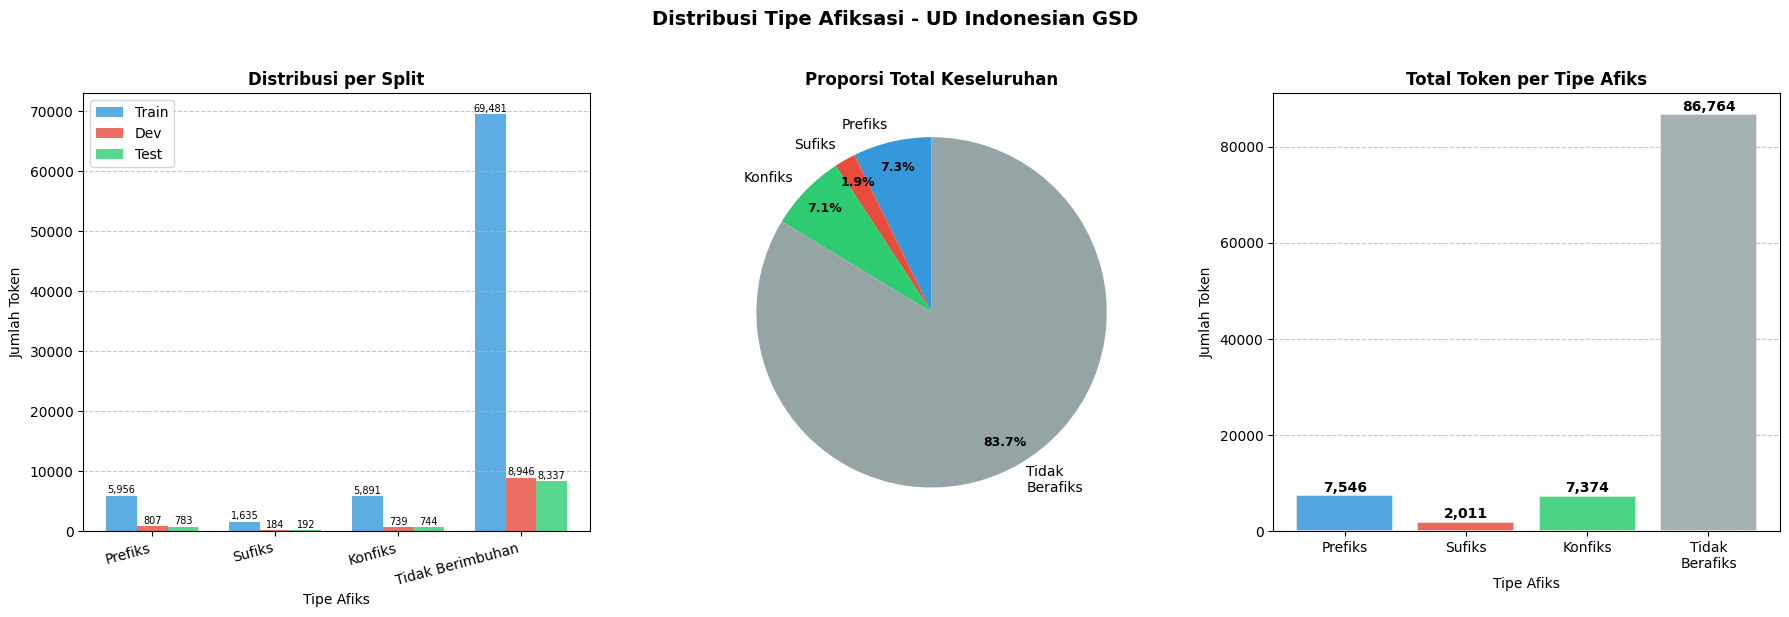

In [10]:
# =================================
# VISUALISASI DISTRIBUSI TIPE AFIKS
# =================================
# Memisahkan kembali df_raw_morph menjadi train, dev, dan test
df_train = df_raw_morph[df_raw_morph['sent_id'].str.contains('train', case=False, na=False)]
df_dev   = df_raw_morph[df_raw_morph['sent_id'].str.contains('dev', case=False, na=False)]
df_test  = df_raw_morph[df_raw_morph['sent_id'].str.contains('test', case=False, na=False)]

# Sesuaikan label dengan output fungsi ekstraksi kita
tipe_list = ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak Berimbuhan']
counts = {}

for tipe in tipe_list:
    c_train = len(df_train[df_train['tipe_afiks'] == tipe])
    c_dev   = len(df_dev[df_dev['tipe_afiks'] == tipe])
    c_test  = len(df_test[df_test['tipe_afiks'] == tipe])
    
    counts[tipe] = {
        'train': c_train,
        'dev'  : c_dev,
        'test' : c_test,
        'total': c_train + c_dev + c_test
    }

# Mapping warna yang konsisten
colors = {
    'Prefiks'         : '#3498db', # Biru
    'Sufiks'          : '#e74c3c', # Merah
    'Konfiks'         : '#2ecc71', # Hijau
    'Tidak Berimbuhan' : '#95a5a6'  # Abu-abu
}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Tipe Afiksasi - UD Indonesian GSD',
             fontsize=14, fontweight='bold', y=1.02)


# PLOT 1: Grouped Bar Chart per Split
ax1    = axes[0]
x      = np.arange(len(tipe_list))
width  = 0.25

bars_train = ax1.bar(x - width, [counts[t]['train'] for t in tipe_list],
                     width, label='Train', color='#3498db', alpha=0.8)
bars_dev   = ax1.bar(x,         [counts[t]['dev']   for t in tipe_list],
                     width, label='Dev',   color='#e74c3c', alpha=0.8)
bars_test  = ax1.bar(x + width, [counts[t]['test']  for t in tipe_list],
                     width, label='Test',  color='#2ecc71', alpha=0.8)

ax1.set_title('Distribusi per Split', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tipe Afiks')
ax1.set_ylabel('Jumlah Token')
ax1.set_xticks(x)
ax1.set_xticklabels(['Prefiks', 'Sufiks', 'Konfiks', 'Tidak Berimbuhan'],
                     rotation=15, ha='right')
ax1.legend()
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

# Anotasi teks di atas bar Plot 1
for bars in [bars_train, bars_dev, bars_test]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + 50,
                     f'{int(height):,}', ha='center', va='bottom', fontsize=7)


# PLOT 2: Pie Chart Total
ax2        = axes[1]
totals     = [counts[t]['total'] for t in tipe_list]
labels     = ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak\nBerafiks'] # \n agar rapi
color_list = [colors[t] for t in tipe_list]

wedges, texts, autotexts = ax2.pie(
    totals,
    labels=labels,
    colors=color_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
)

# Pertebal font persentase di dalam pie
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

ax2.set_title('Proporsi Total Keseluruhan', fontsize=12, fontweight='bold')


# PLOT 3: Bar Chart Total per Tipe Afiks
ax3        = axes[2]
bar_colors = [colors[t] for t in tipe_list]
bars       = ax3.bar(
    ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak\nBerafiks'],
    totals,
    color=bar_colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

ax3.set_title('Total Token per Tipe Afiks', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tipe Afiks')
ax3.set_ylabel('Jumlah Token')
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

# Anotasi teks di atas bar Plot 3
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 100,
             f'{int(height):,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 5. Simpan Data yang Sudah Diproses

In [11]:
# ============================================
# SIMPAN DATA KE CSV
# ============================================
BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Morfologi_Afiksasi"

# Pastikan direktori sudah ada, jika belum buat
os.makedirs(BASE_PROCESSED, exist_ok=True)

# Definisikan nama file
file_train = os.path.join(BASE_PROCESSED, "ud-indo-gsd_train_morph.csv")
file_dev   = os.path.join(BASE_PROCESSED, "ud-indo-gsd_dev_morph.csv")
file_test  = os.path.join(BASE_PROCESSED, "ud-indo-gsd_test_morph.csv")

# Ekspor ke CSV
df_train.to_csv(file_train, index=False, encoding='utf-8')
df_dev.to_csv(file_dev, index=False, encoding='utf-8')
df_test.to_csv(file_test, index=False, encoding='utf-8')

# Print status sesuai format yang diminta
print(f"✓ Train : {len(df_train)} token")
print(f"✓ Dev   : {len(df_dev)} token")
print(f"✓ Test  : {len(df_test)} token")
print(f"✓ Disimpan: ud-indo-gsd_train_morph.csv")
print(f"✓ Disimpan: ud-indo-gsd_dev_morph.csv")
print(f"✓ Disimpan: ud-indo-gsd_test_morph.csv\n")
print("Semua data berhasil disimpan! ✅")

✓ Train : 82963 token
✓ Dev   : 10676 token
✓ Test  : 10056 token
✓ Disimpan: ud-indo-gsd_train_morph.csv
✓ Disimpan: ud-indo-gsd_dev_morph.csv
✓ Disimpan: ud-indo-gsd_test_morph.csv

Semua data berhasil disimpan! ✅


## B. POS Tagging

Pada probing task ini tidak diperlukan preprocessing data apapun, karena data pada POS Tagging IndoLEM bisa langsung digunakan.

### 1. Visualisasi Data

=== VISUALISASI DISTRIBUSI LABEL POS TAGGING DAN SPLIT DATA ===



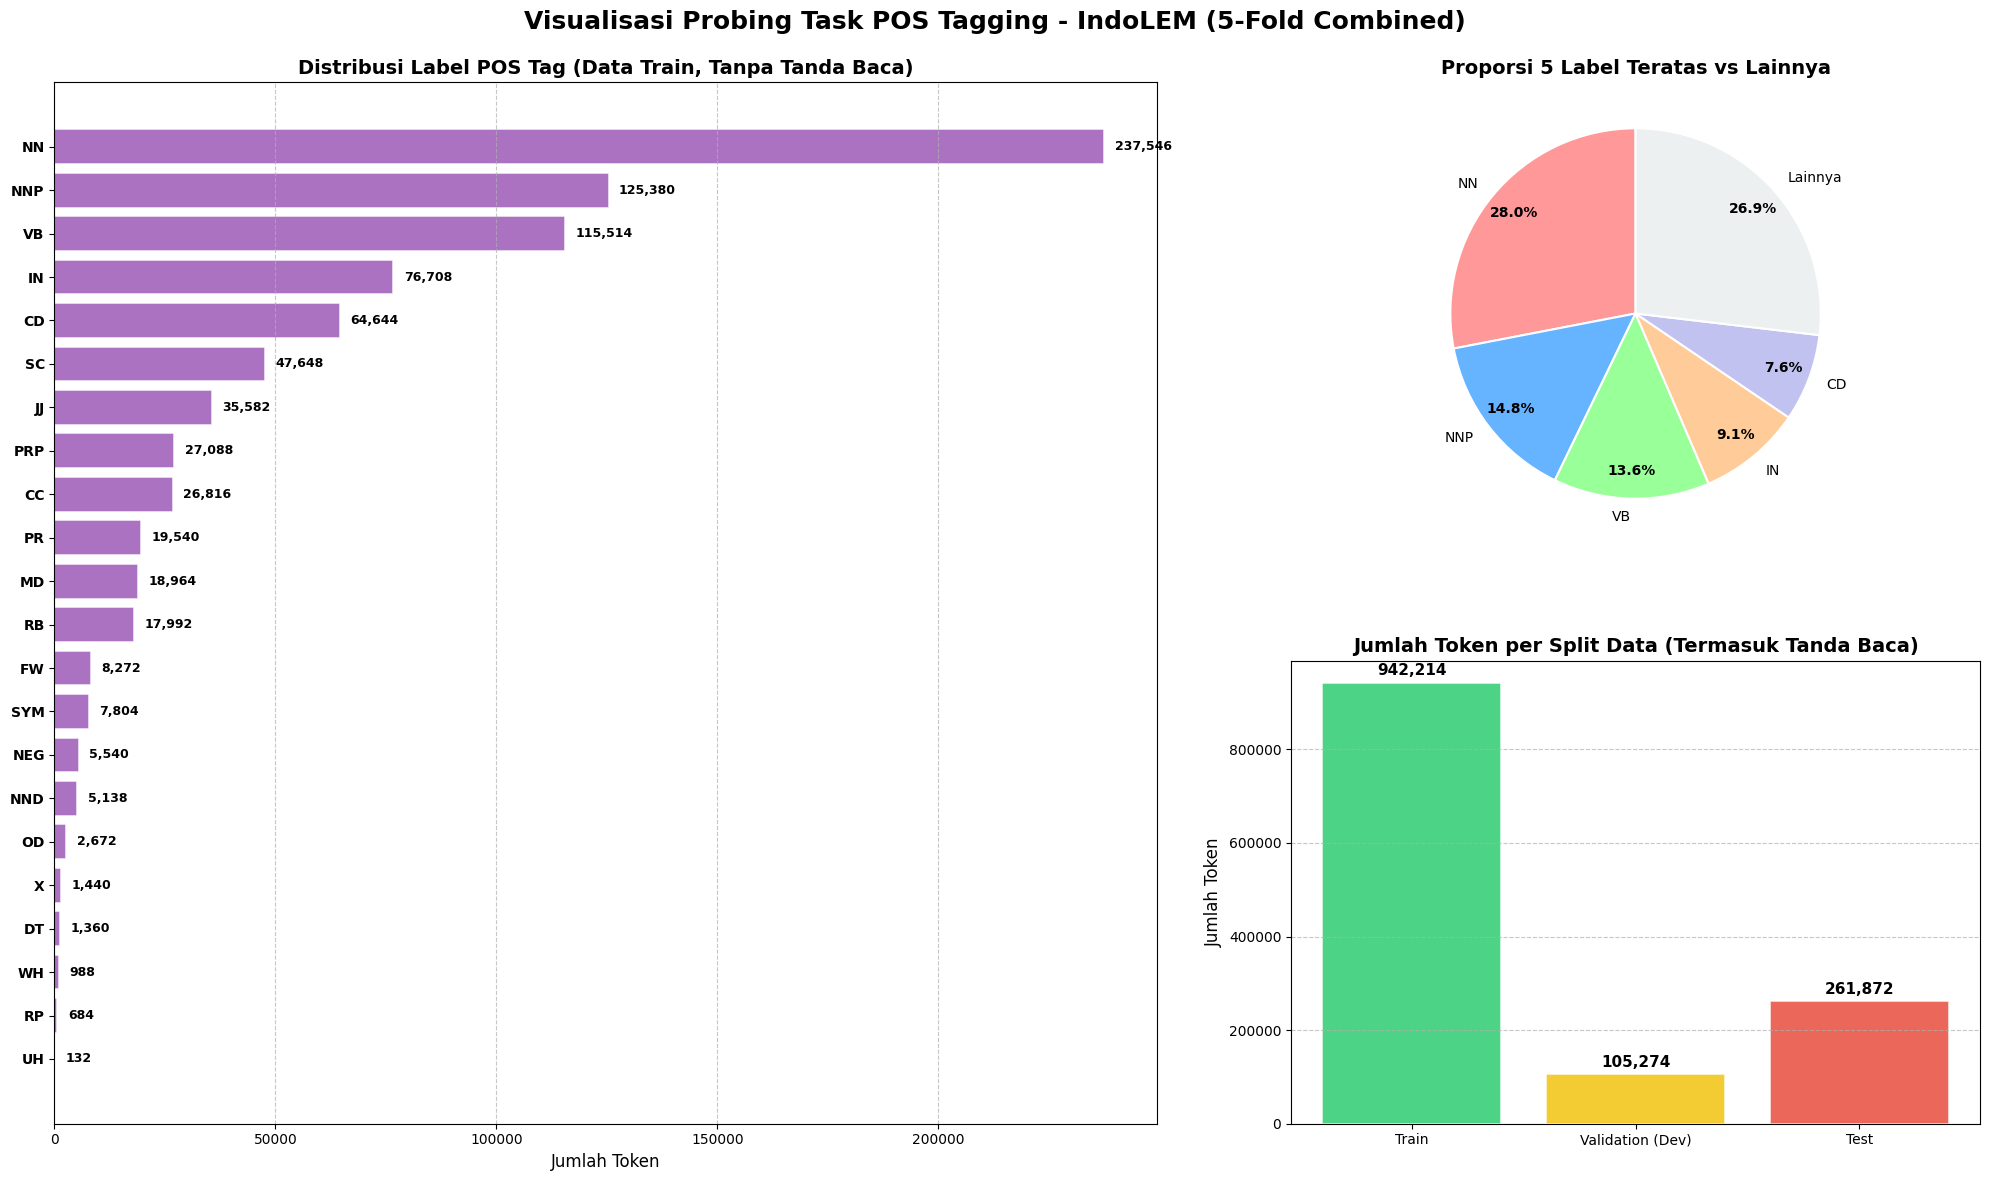

In [ ]:
# ============================================
# FUNGSI EKSTRAKSI DATA POS TAGGING KE DATAFRAME
# ============================================
def extract_pos_data(sentences_list, split_name):
    rows = []
    sent_id_counter = 1
    
    for kalimat in sentences_list:
        lines = kalimat.split('\n')
        token_id = 1
        
        for line in lines:
            parts = line.split('\t')
            if len(parts) == 2:
                rows.append({
                    "sent_id": f"{split_name}_{sent_id_counter}",
                    "token_id": token_id,
                    "token": parts[0],
                    "pos_tag": parts[1]
                })
                token_id += 1
        sent_id_counter += 1
        
    return pd.DataFrame(rows)

# Ekstrak list kalimat menjadi DataFrame terpisah
df_pos_train_split = extract_pos_data(data_pos_train, "train")
df_pos_dev_split   = extract_pos_data(data_pos_dev, "dev")
df_pos_test_split  = extract_pos_data(data_pos_test, "test")

# ============================================
# VISUALISASI DISTRIBUSI LABEL & SPLIT DATA
# ============================================
print("=== VISUALISASI DISTRIBUSI LABEL POS TAGGING DAN SPLIT DATA ===\n")

# Menghitung frekuensi label pada data train (kecuali tanda baca 'Z' agar lebih representatif)
pos_counts = df_pos_train_split[df_pos_train_split['pos_tag'] != 'Z']["pos_tag"].value_counts()

# Menyiapkan data untuk Pie Chart (Top 5 + Lainnya)
top_5 = pos_counts.head(5)
others_count = pos_counts.iloc[5:].sum()
pie_labels = top_5.index.tolist() + ['Lainnya']
pie_counts = top_5.values.tolist() + [others_count]

# Menyiapkan data untuk Bar Chart Split
split_labels = ['Train', 'Validation (Dev)', 'Test']
split_counts = [len(df_pos_train_split), len(df_pos_dev_split), len(df_pos_test_split)]

# Membuat Figure dan GridSpec
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.6, 1], height_ratios=[1, 1])
fig.suptitle('Visualisasi Probing Task POS Tagging - IndoLEM (5-Fold Combined)', 
             fontsize=18, fontweight='bold')

# ---------------------
# Horizontal Bar Chart
# ---------------------
ax1 = plt.subplot(gs[:, 0]) 
y_pos = range(len(pos_counts))
bars1 = ax1.barh(y_pos, pos_counts.values, color='#9b59b6', alpha=0.85, edgecolor='white', linewidth=1.2)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(pos_counts.index, fontweight='bold', fontsize=10)
ax1.invert_yaxis()  
ax1.set_title('Distribusi Label POS Tag (Data Train, Tanpa Tanda Baca)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Jumlah Token', fontsize=12)
ax1.xaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + (max(pos_counts.values)*0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontweight='bold', fontsize=9)

# ------------------
# Plot 2: Pie Chart 
# ------------------
ax2 = plt.subplot(gs[0, 1]) 
colors_pie = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ecf0f1']
wedges, texts, autotexts = ax2.pie(
    pie_counts, labels=pie_labels, colors=colors_pie[:len(pie_labels)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
ax2.set_title('Proporsi 5 Label Teratas vs Lainnya', fontweight='bold', fontsize=14)

# --------------------------
# Plot 3: Vertical Bar Chart 
# --------------------------
ax3 = plt.subplot(gs[1, 1]) 
colors_split = ['#2ecc71', '#f1c40f', '#e74c3c']
bars3 = ax3.bar(split_labels, split_counts, color=colors_split, alpha=0.85, edgecolor='white', linewidth=1.2)
ax3.set_title('Jumlah Token per Split Data (Termasuk Tanda Baca)', fontweight='bold', fontsize=14)
ax3.set_ylabel('Jumlah Token', fontsize=12)
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + (max(split_counts)*0.01), 
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92, wspace=0.15, hspace=0.25)
plt.show()

### 2. Simpan Data dalam File CSV

In [ ]:
# ============================================
# MENYIMPAN DATASET POS TAGGING KE CSV
# ============================================

BASE_PROCESSED_POS = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\POS_Tagging"
os.makedirs(BASE_PROCESSED_POS, exist_ok=True)

# Path lengkap untuk menyimpan file
train_path_pos = os.path.join(BASE_PROCESSED_POS, "indolem_train_pos.csv")
dev_path_pos   = os.path.join(BASE_PROCESSED_POS, "indolem_dev_pos.csv")
test_path_pos  = os.path.join(BASE_PROCESSED_POS, "indolem_test_pos.csv")

# Menyimpan dataframe ke CSV tanpa index
df_pos_train_split.to_csv(train_path_pos, index=False, encoding="utf-8")
df_pos_dev_split.to_csv(dev_path_pos, index=False, encoding="utf-8")
df_pos_test_split.to_csv(test_path_pos, index=False, encoding="utf-8")

print("=== STATUS PENYIMPANAN DATA POS TAGGING ===")
print(f"✓ Train : {len(df_pos_train_split):,} token")
print(f"✓ Dev   : {len(df_pos_dev_split):,} token")
print(f"✓ Test  : {len(df_pos_test_split):,} token")

=== STATUS PENYIMPANAN DATA POS TAGGING ===
✓ Train : 942,214 token
✓ Dev   : 105,274 token
✓ Test  : 261,872 token


# Data Annotator

## A. Convert From CoNLL-U to CSV (UD-Indonesian_GSD)

### 1. Set Path

In [ ]:
# Direktori CSV untuk Morfologi Afiksasi (non-punct)
OUTPUT_DIR_MORFOLOGI = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\all_csv_ud-indonesian-gsd\morfologi_afiksasi"
 
# Direktori CSV untuk Negation Scope Detection (dengan punct, hanya kalimat negasi)
OUTPUT_DIR_NEGASI    = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\all_csv_ud-indonesian-gsd\negation_scope_detection"

### 2. Fungsi Parse dan Konversi

In [ ]:
# =========================
# PARSE CONLLU → DATAFRAME
# =========================
 
def parse_conllu_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return conllu.parse(f.read())
 
def conllu_to_dataframe(sentences, exclude_punct=False, only_negation=False):
    rows = []
 
    for kalimat in sentences:
        sent_id = kalimat.metadata.get('sent_id', '')
        teks    = kalimat.metadata.get('text', '')
 
        # ── Filter kalimat negasi (Polarity=Neg di feats) ──────────
        if only_negation:
            ada_negasi = False
            for token in kalimat:
                if (isinstance(token['id'], int)
                        and token['feats']
                        and "'Polarity': 'Neg'" in str(token['feats'])):
                    ada_negasi = True
                    break
            if not ada_negasi:
                continue
        # ────────────────────────────────────────────────────────────
 
        for token in kalimat:
            if not isinstance(token['id'], int):
                continue
            if exclude_punct and token['upos'] == 'PUNCT':
                continue
 
            rows.append({
                'sent_id'  : sent_id,
                'teks'     : teks,
                'token_id' : token['id'],
                'token'    : token['form'],
                'lemma'    : token['lemma'],
                'upos'     : token['upos'],
                'xpos'     : token['xpos'],
                'feats'    : str(token['feats']) if token['feats'] else '_',
                'head'     : token['head'],
                'deprel'   : token['deprel'],
                'misc'     : str(token['misc']) if token['misc'] else '_',
            })
 
    return pd.DataFrame(rows)
 
 
splits = {
    'train' : PATH_GSD_TRAIN,
    'dev'   : PATH_GSD_DEV,
    'test'  : PATH_GSD_TEST,
}
 
raw_sentences = {split: parse_conllu_file(path) for split, path in splits.items()}

### 3. Menyimpan Data Keseluruhan Morfologi Afiksasi (non tanda baca)

In [ ]:
df_morfologi = {}
rows_morf    = []
 
print("=== STATISTIK TOKEN PER SPLIT — MORFOLOGI AFIKSASI (TANPA TANDA BACA) ===\n")
 
for split_name, sentences in raw_sentences.items():
    df = conllu_to_dataframe(sentences, exclude_punct=True, only_negation=False)
    df_morfologi[split_name] = df
    rows_morf.append({
        'Split'   : split_name,
        'Kalimat' : len(sentences),
        'Token (exc. PUNCT)'   : len(df),
    })
 
df_stat_morf = pd.DataFrame(rows_morf)
df_stat_morf.loc[len(df_stat_morf)] = [
    'TOTAL',
    df_stat_morf['Kalimat'].sum(),
    df_stat_morf['Token (exc. PUNCT)'].sum(),
]
display(df_stat_morf.reset_index(drop=True))
 
# Simpan
os.makedirs(OUTPUT_DIR_MORFOLOGI, exist_ok=True)
total_tersimpan_morf = 0
 
print("\nStatus penyimpanan (Morfologi Afiksasi):")
for split_name, df in df_morfologi.items():
    out_path = os.path.join(OUTPUT_DIR_MORFOLOGI, f"all_ud-indo-gsd_morfologi_{split_name}.csv")
    try:
        df.to_csv(out_path, index=False, encoding='utf-8-sig')
        status = '✅ BERHASIL'
        total_tersimpan_morf += len(df)
    except Exception as e:
        status = f'❌ GAGAL ({e})'
    print(f"  [{status}] all_ud-indo-gsd_morfologi_{split_name}.csv  →  {len(df):,} token")
 
print(f"\nTotal token tersimpan : {total_tersimpan_morf:,} token")

=== STATISTIK TOKEN PER SPLIT — MORFOLOGI AFIKSASI (TANPA TANDA BACA) ===



,Split,Kalimat,Token (exc. PUNCT)
0,train,4477,82963
1,dev,559,10676
2,test,557,10056
3,TOTAL,5593,103695



Status penyimpanan (Morfologi Afiksasi):
  [✅ BERHASIL] all_ud-indo-gsd_morfologi_train.csv  →  82,963 token
  [✅ BERHASIL] all_ud-indo-gsd_morfologi_dev.csv  →  10,676 token
  [✅ BERHASIL] all_ud-indo-gsd_morfologi_test.csv  →  10,056 token

Total token tersimpan : 103,695 token


## B. Pembuatan Sample

### 1. Affixtional Morphology Classification (Token Level)

#### a. Perhitungan Jumlah Sample yang Diambil (Formula Taro Yamane)

Formula Taro Yamane digunakan untuk menentukan jumlah sampel dari populasi yang telah diketahui dengan mempertimbangkan batas toleransi error dari sampel yang diambil.

$$n = \frac{N}{1 + N(e)^2}$$

**Keterangan:**
- $n$ = Jumlah sampel yang dibutuhkan
- $N$ = Jumlah populasi keseluruhan
- $e$ = Batas toleransi kesalahan kesalahan sample *(margin of error)*

In [ ]:
# ========================
# DIRECTORY SAMPLING DATA
# ========================

OUTPUT_SAMPLING_MORF_CSV   = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\a_pre_anotasi_sampel\csv"
OUTPUT_SAMPLING_MORF_EXCEL = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\a_pre_anotasi_sampel\excel"
 
os.makedirs(OUTPUT_SAMPLING_MORF_CSV,   exist_ok=True)
os.makedirs(OUTPUT_SAMPLING_MORF_EXCEL, exist_ok=True)

In [ ]:
# ==============================
# HITUNG YAMANE PER SPLIT
# ==============================

e = 0.05  # margin of error 5%
 
rows_yamane_morf = []
 
print("=== SAMPLE SIZE PER SPLIT — MORFOLOGI AFIKSASI (TANPA TANDA BACA) ===")
 
for split_name, df in df_morfologi.items():
    N = len(df)
    n = round(N / (1 + N * (e ** 2)))
    rows_yamane_morf.append({
        'Split'        : split_name,
        'Populasi (N)' : N,
        'Sample (n)'   : n,
    })
 
df_yamane_morf = pd.DataFrame(rows_yamane_morf)
df_yamane_morf.loc[len(df_yamane_morf)] = [
    'TOTAL',
    df_yamane_morf['Populasi (N)'].sum(),
    df_yamane_morf['Sample (n)'].sum(),
]
display(df_yamane_morf.reset_index(drop=True))
print(f"Margin of error (e) : {e} ({int(e*100)}%)")

=== SAMPLE SIZE PER SPLIT — MORFOLOGI AFIKSASI (TANPA TANDA BACA) ===


,Split,Populasi (N),Sample (n)
0,train,82963,398
1,dev,10676,386
2,test,10056,385
3,TOTAL,103695,1169


Margin of error (e) : 0.05 (5%)


#### b. Pemilihan Sample Secara Random

In [ ]:
# ==============================
# RANDOM SAMPLING & SIMPAN 
# ==============================

ANNOTATION_COLUMNS_MORF = [
    'sent_id', 'teks', 'token_id', 'token', 'lemma',
    'upos', 'xpos', 'feats', 'head', 'deprel', 'misc',
    'tipe_afiks',
]
 
print("=== RANDOM SAMPLING & SIMPAN TEMPLATE ANOTASI — MORFOLOGI AFIKSASI ===")
print()
 
for row in rows_yamane_morf:
    split_name = row['Split']
    n          = row['Sample (n)']
    df         = df_morfologi[split_name]
 
    # Sampling acak
    df_sample = df.sample(n=n, random_state=42).reset_index(drop=True)
 
    # Tambah kolom anotasi kosong
    df_sample['tipe_afiks'] = ''
 
    # Pastikan urutan kolom sesuai template
    df_sample = df_sample[ANNOTATION_COLUMNS_MORF]
 
    path_csv   = os.path.join(OUTPUT_SAMPLING_MORF_CSV,   f"morfologiAfiksasi_sample_{split_name}.csv")
    path_excel = os.path.join(OUTPUT_SAMPLING_MORF_EXCEL, f"morfologiAfiksasi_sample_{split_name}.xlsx")
 
    # Simpan CSV
    try:
        df_sample.to_csv(path_csv, index=False, encoding='utf-8-sig')
        status_csv = '✅ BERHASIL'
    except Exception as ex:
        status_csv = f'❌ GAGAL ({ex})'
 
    # Simpan Excel (lebar kolom disesuaikan)
    try:
        with pd.ExcelWriter(path_excel, engine='openpyxl') as writer:
            df_sample.to_excel(writer, index=False, sheet_name='Anotasi')
 
            ws = writer.sheets['Anotasi']
 
            col_widths = {
                'sent_id'    : 10,
                'teks'       : 60,
                'token_id'   : 5,
                'token'      : 18,
                'lemma'      : 18,
                'upos'       : 12,
                'xpos'       : 15,
                'feats'      : 30,
                'head'       : 10,
                'deprel'     : 15,
                'misc'       : 50,
                'tipe_afiks' : 20,
            }
            for i, col_name in enumerate(ANNOTATION_COLUMNS_MORF, start=1):
                col_letter = ws.cell(row=1, column=i).column_letter
                ws.column_dimensions[col_letter].width = col_widths.get(col_name, 15)
 
        status_excel = '✅ BERHASIL'
    except Exception as ex:
        status_excel = f'❌ GAGAL ({ex})'
 
    print(f"[{split_name}]  {n:,} token acak diambil dari {row['Populasi (N)']:,} token")
    print(f"  CSV   [{status_csv}]")
    print(f"  Excel [{status_excel}]")
    print()
 
print("Status: Proses sampling selesai.")

=== RANDOM SAMPLING & SIMPAN TEMPLATE ANOTASI — MORFOLOGI AFIKSASI ===

[train]  398 token acak diambil dari 82,963 token
  CSV   [✅ BERHASIL]
  Excel [✅ BERHASIL]

[dev]  386 token acak diambil dari 10,676 token
  CSV   [✅ BERHASIL]
  Excel [✅ BERHASIL]

[test]  385 token acak diambil dari 10,056 token
  CSV   [✅ BERHASIL]
  Excel [✅ BERHASIL]

Status: Proses sampling selesai.


# C. Silver Standard Annotation — Morfologi Afiksasi

## 1. Set Path

In [4]:
BASE_PATH = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky"
 
DIR_ANNOTATOR = os.path.join(BASE_PATH, "data", "anotasi", "morfologi_afiksasi", "b_post_anotasi")
DIR_MERGE     = os.path.join(BASE_PATH, "data", "anotasi", "morfologi_afiksasi", "c_merge_anotasi")
 
os.makedirs(DIR_MERGE, exist_ok=True)
 
SPLITS      = ["train", "dev", "test"]
LABEL_COL   = "tipe_afiks"
ID_COLS     = ["sent_id", "token_id", "token"]

## 2. Merge Hasil Anotasi

**Keterangan Merge Data**

Merge dilakukan untuk menyatukan hasil anotasi dari beberapa annotator berdasarkan ID/unit data yang sama. Proses ini bertujuan agar label dari setiap annotator dapat dibandingkan pada item yang identik dalam perhitungan Inter-Annotator Agreement (IAA).

Dengan kata lain, merge dilakukan untuk menyelaraskan data sebelum perhitungan Inter-Annotator Agreement (IAA) dilakukan.

### a. Fungsi Merge

In [8]:
def merge_anotasi(split: str) -> pd.DataFrame:
    dfs = {}
    for i in range(1, 4):
        path = os.path.join(
            DIR_ANNOTATOR, f"annotator_{i}",
            f"{i}_morfologiAfiksasi_sample_{split}.csv"
        )
        df = pd.read_csv(path, encoding="utf-8-sig")
        df = df.rename(columns={LABEL_COL: f"Annotator_{i}"})
        dfs[i] = df

    BASE_COLS = [
        "sent_id", "teks", "token_id", "token", "lemma",
        "upos", "xpos", "feats", "head", "deprel", "misc"
    ]

    df_merged = dfs[1][BASE_COLS + ["Annotator_1"]].copy()
    df_merged = df_merged.merge(
        dfs[2][["sent_id", "token_id", "Annotator_2"]],
        on=["sent_id", "token_id"], how="left"
    )
    df_merged = df_merged.merge(
        dfs[3][["sent_id", "token_id", "Annotator_3"]],
        on=["sent_id", "token_id"], how="left"
    )

    return df_merged

### b. Jalankan Merge & Simpan

In [10]:
print("=" * 60)
print("  STEP 4 — MERGE HASIL ANOTASI (3 ANOTATOR)")
print("=" * 60)

df_merged_all = {}

for split in SPLITS:
    print(f"\n[{split.upper()}]")

    df_merged = merge_anotasi(split)
    df_merged_all[split] = df_merged

    path_out = os.path.join(DIR_MERGE, f"morfologiAfiksasi_merged_{split}.csv")
    df_merged.to_csv(path_out, index=False, encoding="utf-8-sig")

    print(f"  Total token  : {len(df_merged)}")
    print(f"  Kolom output : {df_merged.columns.tolist()}")
    print(f"  ✅ Tersimpan → {path_out}")

print("\n[SELESAI] Merge semua split selesai.")

  STEP 4 — MERGE HASIL ANOTASI (3 ANOTATOR)

[TRAIN]
  Total token  : 398
  Kolom output : ['sent_id', 'teks', 'token_id', 'token', 'lemma', 'upos', 'xpos', 'feats', 'head', 'deprel', 'misc', 'Annotator_1', 'Annotator_2', 'Annotator_3']
  ✅ Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\c_merge_anotasi\morfologiAfiksasi_merged_train.csv

[DEV]
  Total token  : 386
  Kolom output : ['sent_id', 'teks', 'token_id', 'token', 'lemma', 'upos', 'xpos', 'feats', 'head', 'deprel', 'misc', 'Annotator_1', 'Annotator_2', 'Annotator_3']
  ✅ Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\c_merge_anotasi\morfologiAfiksasi_merged_dev.csv

[TEST]
  Total token  : 385
  Kolom output : ['sent_id', 'teks', 'token_id', 'token', 'lemma', 'upos', 'xpos', 'feats', 'head', 'deprel', 'misc', 'Annotator_1', 'A

## 3. Inter-Annotator Agreement (IAA) - Fleiss' Kappa

**Fleiss' Kappa** dipilih berdasarkan kebutuhan utama dalam penelitian ini, yaitu untuk menghitung tingkat agreement antar 3 anotator untuk label pada jenis data kategorikal, yang mana kebutuhan tersebut dapat diakomodir oleh pendekatan mentode Fleiss' Kappa.

### a. Fungsi Fleiss' Kappa

In [ ]:
ANNOTATOR_COLS = ["Annotator_1", "Annotator_2", "Annotator_3"]

# Fungsi interpretasi nilai Kappa dibuat berdasarkan paper Landis & Koch (1977)
def interpretasi_kappa(k):
    if   k < 0.00: return "Poor Agreement"
    elif k < 0.20: return "Slight Agreement"
    elif k < 0.40: return "Fair Agreement"
    elif k < 0.60: return "Moderate Agreement"
    elif k < 0.80: return "Substantial Agreement"
    else:          return "Almost Perfect Agreement"

def hitung_fleiss_kappa(df):
    labels   = df[ANNOTATOR_COLS].values          # Ambil hanya kolom anotator
    cats     = sorted(set(labels.flatten()))      # Kategori (misal: Prefiks, Sufiks, Konfiks, Tidak Berimbuhan)
    n, k_ann = len(labels), labels.shape[1]       # Jumlah token, jumlah anotator

    # freq: menghitung berapa anotator yang memilih setiap kategori untuk tiap token
    freq = np.array([[np.sum(row == c) for c in cats] for row in labels])

    # Fleiss' Kappa
    p_j  = freq.sum(axis=0) / (n * k_ann)                               # proporsi anotasi untuk setiap kategori
    P_e  = np.sum(p_j ** 2)                                             # proporsi kesepakatan yang diharapkan secara acak
    P_i  = (np.sum(freq**2, axis=1) - k_ann) / (k_ann * (k_ann - 1))    # proporsi kesepakatan untuk setiap token
    P_o_fleiss = P_i.mean()                                             # proporsi kesepakatan aktual rata-rata per token
    kappa = (P_o_fleiss - P_e) / (1 - P_e)                              # rumus Fleiss' Kappa

    return round(kappa, 4)


### b. Jalankan Perhitungan Agreement - Fleiss' Kappa

In [44]:
print("=" * 60)
print("\t\t   HASIL FLEISS' KAPPA")
print("=" * 60 + "\n")
print(f"  {'Split':<10} {'Nilai Kappa (κ)':>15}  {'Strength of Agreement':<25}")
print(f"  {'-'*55}")

kappas = []
for split in SPLITS:
    kappa = hitung_fleiss_kappa(df_merged_all[split])
    kappas.append(kappa)
    print(f"  {split:<10} {kappa:>15.4f}  {interpretasi_kappa(kappa):<25}")

avg = round(np.mean(kappas), 4)
print(f"  {'-'*55}")
print(f"  {'Rata-rata':<10} {avg:>15.4f}  {interpretasi_kappa(avg):<25}")
print("\n"+"=" * 60 )

		   HASIL FLEISS' KAPPA

  Split      Nilai Kappa (κ)  Strength of Agreement    
  -------------------------------------------------------
  train               0.9894  Almost Perfect Agreement 
  dev                 1.0000  Almost Perfect Agreement 
  test                0.9942  Almost Perfect Agreement 
  -------------------------------------------------------
  Rata-rata           0.9945  Almost Perfect Agreement 



**Hasil:** Ketiga annotator hampir sepenuhnya sepakat dalam memberi label tipe_afiks dalam morfologi afiksasi.

## 4. Conflict Resolution — Majority Voting

In [53]:
DIR_RESOLVED = os.path.join(BASE_PATH, "data", "anotasi", "morfologi_afiksasi", "d_Silver_Standard")
os.makedirs(DIR_RESOLVED, exist_ok=True)

def majority_voting(row):
    labels = [row["Annotator_1"], row["Annotator_2"], row["Annotator_3"]]
    counts = pd.Series(labels).value_counts()
    if counts.iloc[0] >= 2:
        return counts.index[0]
    return "REVIEW"

def conflict_type(row):
    labels = {row["Annotator_1"], row["Annotator_2"], row["Annotator_3"]}
    if len(labels) == 1: return "Agree"
    if len(labels) == 2: return "Conflict Majority" # Conflict 2v1
    return "Conflict NoMajority" # Conflict 3-way

print("=" * 60)
print("  CONFLICT RESOLUTION: MAJORITY VOTING")
print("=" * 60)

df_resolved_all = {}

for split in SPLITS:
    df = df_merged_all[split].copy()

    df["conflict_type"]  = df.apply(conflict_type,    axis=1)
    df["silver_label"]   = df.apply(majority_voting,  axis=1)

    n_total    = len(df)
    n_agree    = (df["conflict_type"] == "Agree").sum()
    n_2v1      = (df["conflict_type"] == "Conflict Majority").sum()
    n_3way     = (df["conflict_type"] == "Conflict NoMajority").sum()
    n_review   = (df["silver_label"]  == "REVIEW").sum()

    df_resolved_all[split] = df

    path_out = os.path.join(DIR_RESOLVED, f"morfologiAfiksasi_SilverStandard_Sample_{split}.csv")
    df.to_csv(path_out, index=False, encoding="utf-8-sig")

    print(f"\n  [{split.upper()}]")
    print(f"  Total token      : {n_total}")
    print(f"  Agree (3/3)      : {n_agree}  ({n_agree/n_total*100:.1f}%)")
    print(f"  Conflict 2v1     : {n_2v1}  ({n_2v1/n_total*100:.1f}%)")
    print(f"  Conflict 3-way   : {n_3way}  ({n_3way/n_total*100:.1f}%)")
    if n_review > 0:
        print(f"  ⚠ Perlu review   : {n_review} token → cek file REVIEW")
    print(f"  ✅ Majority Voting Berhasil Dilakukan & Telah Tersimpan → {path_out}")

print(f"\n[SELESAI] Majority voting selesai.")

  CONFLICT RESOLUTION: MAJORITY VOTING

  [TRAIN]
  Total token      : 398
  Agree (3/3)      : 396  (99.5%)
  Conflict 2v1     : 2  (0.5%)
  Conflict 3-way   : 0  (0.0%)
  ✅ Majority Voting Berhasil Dilakukan & Telah Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\d_Silver_Standard\morfologiAfiksasi_SilverStandard_Sample_train.csv

  [DEV]
  Total token      : 386
  Agree (3/3)      : 386  (100.0%)
  Conflict 2v1     : 0  (0.0%)
  Conflict 3-way   : 0  (0.0%)
  ✅ Majority Voting Berhasil Dilakukan & Telah Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\d_Silver_Standard\morfologiAfiksasi_SilverStandard_Sample_dev.csv

  [TEST]
  Total token      : 385
  Agree (3/3)      : 384  (99.7%)
  Conflict 2v1     : 1  (0.3%)
  Conflict 3-way   : 0  (0.0%)
  ✅ Majority Voting Berhasil Dilakukan 

## 5. Validasi Akurasi - Data Hasil Feature Extraction Terhadap Sampel Silver Standard Annotation

### a. Set Path & Load Data

In [75]:
# ── Path full dataset (label otomatis) ────────────────────────
DIR_PROCESSED = os.path.join(BASE_PATH, "data", "processed", "Morfologi_Afiksasi")

PATH_FULL = {
    "train": os.path.join(DIR_PROCESSED, "ud-indo-gsd_train_morph.csv"),
    "dev"  : os.path.join(DIR_PROCESSED, "ud-indo-gsd_dev_morph.csv"),
    "test" : os.path.join(DIR_PROCESSED, "ud-indo-gsd_test_morph.csv"),
}

# ── Path silver standard (hasil majority voting) ──────────────
DIR_SILVER = os.path.join(BASE_PATH, "data", "anotasi", "morfologi_afiksasi", "d_Silver_Standard")

PATH_SILVER = {
    "train": os.path.join(DIR_SILVER, "morfologiAfiksasi_SilverStandard_Sample_train.csv"),
    "dev"  : os.path.join(DIR_SILVER, "morfologiAfiksasi_SilverStandard_Sample_dev.csv"),
    "test" : os.path.join(DIR_SILVER, "morfologiAfiksasi_SilverStandard_Sample_test.csv"),
}

### b. Fungsi Validasi

In [ ]:
def validasi_akurasi(split: str) -> dict:
    """
    Join full dataset (label otomatis) dengan silver standard (label tervalidasi)
    berdasarkan sent_id + token_id, lalu hitung akurasi per label dan overall.
    Hanya token dengan silver_label != 'REVIEW' yang dihitung.
    """
    df_full   = pd.read_csv(PATH_FULL[split],   encoding="utf-8-sig")
    df_silver = pd.read_csv(PATH_SILVER[split], encoding="utf-8-sig")

    # Hanya pakai token yang sudah resolved (bukan REVIEW)
    df_silver = df_silver[df_silver["silver_label"] != "REVIEW"].copy()

    # Join berdasarkan sent_id + token_id
    df_join = df_silver[["sent_id", "token_id", "token", "silver_label"]].merge(
        df_full[["sent_id", "token_id", "tipe_afiks"]],
        on=["sent_id", "token_id"],
        how="left"
    )

    # Hapus baris yang tidak match 
    df_join = df_join.dropna(subset=["tipe_afiks"])

    # Bandingkan label otomatis vs silver standard
    df_join["cocok"] = df_join["tipe_afiks"] == df_join["silver_label"]

    total   = len(df_join)
    n_cocok = df_join["cocok"].sum()
    akurasi = n_cocok / total

    # Akurasi per kelas
    per_kelas = {}
    for label in sorted(df_join["silver_label"].unique()):
        mask     = df_join["silver_label"] == label
        n_kelas  = mask.sum()
        n_benar  = (df_join.loc[mask, "cocok"]).sum()
        per_kelas[label] = {
            "n"      : int(n_kelas),
            "benar"  : int(n_benar),
            "akurasi": round(n_benar / n_kelas, 4) if n_kelas > 0 else 0.0,
        }

    return {
        "split"    : split,
        "total"    : total,
        "n_cocok"  : int(n_cocok),
        "akurasi"  : round(akurasi, 4),
        "per_kelas": per_kelas,
        "df_join"  : df_join,
    }

### c. Jalankan Validasi & Tampilkan Hasil

In [86]:
print("=" * 70)
print("  REKAPITULASI VALIDASI AKURASI LABEL OTOMATIS vs SILVER STANDARD")
print("=" * 70)
print(f"  {'Split':<30} {'Token':>8}  {'Cocok':>8}  {'Akurasi':>10}")
print(f"  {'-'*68}")

hasil_validasi = {}
for split in SPLITS:
    hasil = validasi_akurasi(split)
    hasil_validasi[split] = hasil
    print(f"  {split:<30} {hasil['total']:>8}  {hasil['n_cocok']:>8}  {hasil['akurasi']*100:>9.2f}%")

total_all   = sum(h["total"]   for h in hasil_validasi.values())
cocok_all   = sum(h["n_cocok"] for h in hasil_validasi.values())
akurasi_all = cocok_all / total_all

print(f"  {'-'*68}")
print(f"  {'TOTAL':<30} {total_all:>8}  {cocok_all:>8}  {akurasi_all*100:>9.2f}%")
print("=" * 70)

  REKAPITULASI VALIDASI AKURASI LABEL OTOMATIS vs SILVER STANDARD
  Split                             Token     Cocok     Akurasi
  --------------------------------------------------------------------
  train                               398       386      96.98%
  dev                                 386       370      95.85%
  test                                385       374      97.14%
  --------------------------------------------------------------------
  TOTAL                              1169      1130      96.66%


**Hasil:**  Proses anotasi yang dilakukan secara rule-based (otomatis) sudah cukup akurat apabila dibandingkan dengan sample dari data yang dianotasikan secara manual

### d. Simpan Hasil Validasi

In [79]:
DIR_VALIDASI = os.path.join(BASE_PATH, "data", "anotasi", "morfologi_afiksasi", "e_Validasi")
os.makedirs(DIR_VALIDASI, exist_ok=True)

for split in SPLITS:
    df_out = hasil_validasi[split]["df_join"][[
        "sent_id", "token_id", "token", "silver_label", "tipe_afiks", "cocok"
    ]].rename(columns={
        "silver_label": "label_silver",
        "tipe_afiks"  : "label_otomatis",
    })

    path_out = os.path.join(DIR_VALIDASI, f"morfologiAfiksasi_validasi_{split}.csv")
    df_out.to_csv(path_out, index=False, encoding="utf-8-sig")
    print(f"  ✅ [{split}] Tersimpan → {path_out}")

print(f"\n📊 Akurasi keseluruhan: {akurasi_all*100:.2f}%")
print(f"   Hasil validasi tersimpan di: {DIR_VALIDASI}")
print("\n[SELESAI] Validasi akurasi selesai.")

  ✅ [train] Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\e_Validasi\morfologiAfiksasi_validasi_train.csv
  ✅ [dev] Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\e_Validasi\morfologiAfiksasi_validasi_dev.csv
  ✅ [test] Tersimpan → D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\e_Validasi\morfologiAfiksasi_validasi_test.csv

📊 Akurasi keseluruhan: 96.66%
   Hasil validasi tersimpan di: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\anotasi\morfologi_afiksasi\e_Validasi

[SELESAI] Validasi akurasi selesai.
